### lgbm_ranker

In this notebook, we implement a LearnToRank LightGBM Ranking model predictor using year-by-year split.

In [1]:
import numpy as np
import csv
import pandas as pd
from itertools import islice
import json
import missingno as msno
import matplotlib.pyplot as plt
import sklearn
import sys

sys.path.append("../scripts")

In [2]:
books_tt = pd.read_csv('../data/books_engineered_train.csv')
books_tt.head()

,Unnamed: 0.1,Unnamed: 0,title,author,release_year,first_publisher,tags,hugo,locus,month_of_publication,...,tag_urban,tag_urban fantasi,tag_vampir,tag_video gam,tag_war,tag_weak character develop,tag_weird,tag_werewolf,tag_ya,tag_zombi
0,4548,4548,The Hawkstone,Jay Williams,1971,Other,[''],False,False,10,...,0,0,0,0,0,0,0,0,0,0
1,4549,4549,"Barnabas, Quentin and Dr. Jekyll's Son",Marilyn Ross,1971,Other,NaN,False,False,04,...,0,0,0,0,0,0,0,0,0,0
2,4550,4550,Swap Around the Ouija,John Dexter,1971,Other,NaN,False,False,Unknown,...,0,0,0,0,0,0,0,0,0,0
3,4551,4551,The Sun Grows Cold,Howard Berk,1971,dell,['apocalyps'],False,False,01,...,0,0,0,0,0,0,0,0,0,0
4,4552,4552,The Seal-Singing,Rosemary Harris,1971,Other,['anim'],False,False,Unknown,...,0,0,0,0,0,0,0,0,0,0


In [3]:
print(books_tt['publisher_historical_nominations'].apply(type).value_counts())

publisher_historical_nominations
<class 'float'>    75108
Name: count, dtype: int64


In [4]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
sys.path.append("../scripts")
from feature_engineering.feature_engineering import tag_dataframe
from custom_yearly_scalers import YearByYearStandardScaler, YearlyGenreTagScaler, YearlyGenreTagScalerJay, YearlyPastNomineeSimilarityScaler
from sklearn.preprocessing import MultiLabelBinarizer, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numerical_features = ["Total_Awards_Previously", "Author_Age_at_Publication", "author_num_books", "years_since_last_nomination", "publisher_historical_nominations", "publisher_cohort_size"]
categorical_features = ["first_publisher", "month_of_publication"]
mlb_features = ["tags"]
bool_features = ["new_author"]

# for each categorical feature, create one-hot encoding
categorical_pipeline = Pipeline(
    steps=[
        ('solve_nans', SimpleImputer(fill_value='Unknown', strategy='constant')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ] 
)

# numerical features: z-score normalization with the rest of the year.
# turn bool features to int
# calculate similarities
feature_preprocessing = ColumnTransformer(
    transformers=[
        ('numerical_scaling', YearByYearStandardScaler(year_column='release_year', scale_columns=numerical_features), numerical_features + ['release_year']),
        ('bool_to_int', FunctionTransformer(lambda x: x.astype(int), feature_names_out='one-to-one'), bool_features),
        ('onehot', categorical_pipeline, categorical_features),
    ('tag_similarity', YearlyGenreTagScaler(tag_columns=list(tag_dataframe.columns), year_column='release_year'), list(tag_dataframe.columns) + ['release_year']) ,
    ('nominee_similarity', YearlyPastNomineeSimilarityScaler(tag_columns=list(tag_dataframe.columns), year_column='release_year'), list(tag_dataframe.columns) + ['release_year'])    ],
)

We use walk-forward nested time series cross-validation

In [5]:
from walkforward_cv import walk_forward

def walk_forward(data, initial_size=5, step=1):
    # data is a data
    years = data['release_year'].unique()
    num_years = len(years)
    splits = []

    for i in range(initial_size, num_years - step + 1):
        # print(num_years - initial_size - step + 1)
        data_start = 0
        data_end = i
        val_start = data_end
        val_end = val_start + step

        window = data[data['release_year'].isin(years[data_start:data_end])]
        val = data[data['release_year'].isin(years[val_start:val_end])]

        splits.append((window, val))

    return splits


windows = walk_forward(books_tt)


In [6]:
print(len(windows))

39


In [7]:
features = numerical_features + categorical_features + list(tag_dataframe.columns) + ['release_year'] + bool_features

import lightgbm as lgb

model_lgb = Pipeline(steps=[
    ('preprocess', feature_preprocessing),
    ('lgb_rank', lgb.LGBMRanker(
        objective="lambdarank",
        n_estimators=300,
        label_gain=[0, 1],
        random_state=42,
        verbose=-1
    ))
])

In [8]:
num_finalists = 60  # the top 60 ranked will be labeled as finalists.
K = 6

from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import average_precision_score, ndcg_score
from sklearn.metrics import recall_score


cv_data_lgb = []
for num, fold in enumerate(windows):
    book_train = fold[0]
    book_val = fold[1]
    book_train = book_train.copy()
    book_val = book_val.copy()
    year = book_val['release_year'].mode()

    # LightGBM needs data sorted by group, with contiguous group sizes
    book_train = book_train.sort_values('release_year')
    group_sizes = book_train.groupby('release_year', sort=True).size().to_numpy()

    model_lgb.fit(
        book_train[features],
        book_train['target'],
        lgb_rank__group=group_sizes,
    )

    ypred = model_lgb.predict(book_val[features])
    book_val['predicted_score'] = ypred
    book_val['rank_within_year'] = book_val.groupby('release_year')['predicted_score'].rank(
        method='first',
        ascending=False
    )

    book_val['predicted'] = (book_val['rank_within_year'] <= num_finalists).astype(int)
    f1score = f1_score(book_val['target'], book_val['predicted'].values)
    recall = recall_score(book_val['target'], book_val['predicted'].values)
    precision = average_precision_score(book_val['target'], book_val['predicted'].values)

    # Precision@6 and NDCG@6, computed per year then averaged over the fold
    prec_at_k_list = []
    ndcg_at_k_list = []
    for yr, grp in book_val.groupby('release_year'):
        y_true = grp['target'].values.astype(int)
        y_score = grp['predicted_score'].values
        if y_true.sum() == 0:
            continue  # no finalists this year, metrics undefined
        top_k = grp.nsmallest(K, 'rank_within_year')
        prec_at_k_list.append(top_k['target'].values.astype(int).sum() / K)
        ndcg_at_k_list.append(ndcg_score([y_true], [y_score], k=K))

    prec_at_6 = np.mean(prec_at_k_list)
    ndcg_at_6 = np.mean(ndcg_at_k_list)

    cv_data_lgb.append({
        'fold': num,
        'val_year': year.values,
        'f1_score': f1score,
        'recall': recall,
        'precision': precision,
        'precision_at_6': prec_at_6,
        'ndcg_at_6': ndcg_at_6,
    })
    print(num)

/home/rudolph/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(


0


/home/rudolph/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(


1


/home/rudolph/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(


...

36


/home/rudolph/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(


37


/home/rudolph/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(


38


In [9]:
cv_result = pd.DataFrame(cv_data_lgb)
print("Mean f1 score across folds: ", cv_result['f1_score'].mean())
print("STD of f1 score across folds: ", cv_result['f1_score'].std())

Mean f1 score across folds:  0.5001525755592089
STD of f1 score across folds:  0.07320924173814838


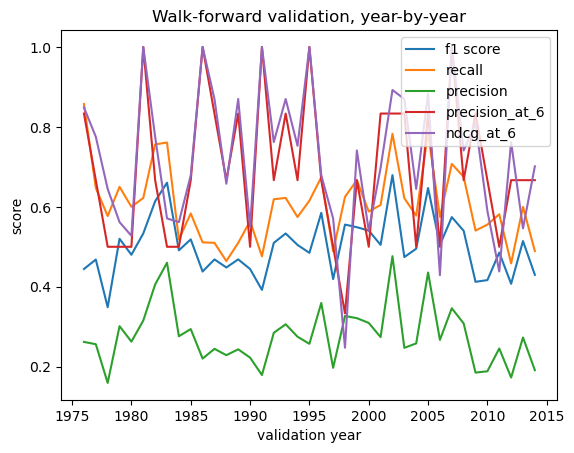

In [10]:
plt.plot([year[0] for year in cv_result['val_year']], cv_result['f1_score'], label='f1 score')
plt.plot([year[0] for year in cv_result['val_year']], cv_result['recall'], label='recall')
plt.plot([year[0] for year in cv_result['val_year']], cv_result['precision'], label='precision')
plt.plot([year[0] for year in cv_result['val_year']], cv_result['precision_at_6'], label='precision_at_6')
plt.plot([year[0] for year in cv_result['val_year']], cv_result['ndcg_at_6'], label='ndcg_at_6')
plt.xlabel("validation year")
plt.ylabel("score")
plt.title('Walk-forward validation, year-by-year')
plt.legend()

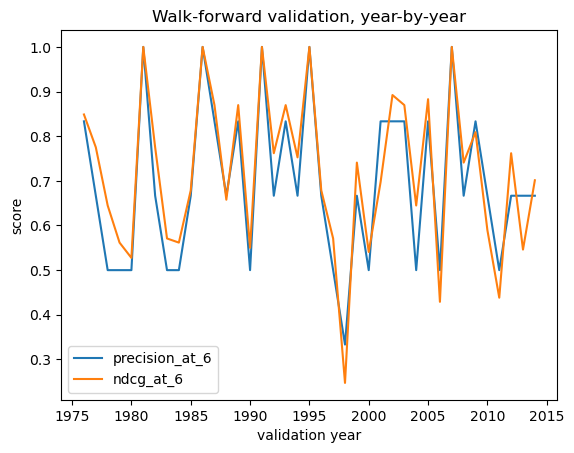

In [11]:
plt.plot([year[0] for year in cv_result['val_year']], cv_result['precision_at_6'], label='precision_at_6')
plt.plot([year[0] for year in cv_result['val_year']], cv_result['ndcg_at_6'], label='ndcg_at_6')
plt.xlabel("validation year")
plt.ylabel("score")
plt.title('Walk-forward validation, year-by-year')
plt.legend()

/home/rudolph/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 5.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<Axes: >

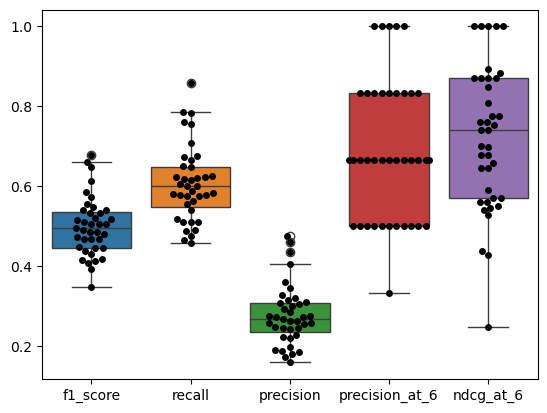

In [12]:
import seaborn as sns


ax = sns.boxplot(data=cv_result[['f1_score', 'recall', 'precision', 'precision_at_6', 'ndcg_at_6']])

sns.swarmplot(data=cv_result[['f1_score', 'recall', 'precision', 'precision_at_6', 'ndcg_at_6']], ax=ax, color='black')

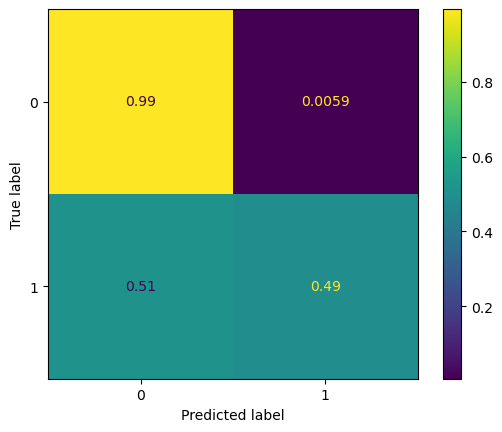

In [13]:
conf = confusion_matrix(book_val['target'], book_val['predicted'], normalize='true')#.ravel().tolist()

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(confusion_matrix=conf).plot()


In [16]:
print("names:", len(feature_names))
print("importances:", len(importances))

names: 82
importances: 82


In [15]:
feature_names = model_lgb.named_steps['preprocess'].get_feature_names_out()

importances = model_lgb.named_steps['lgb_rank'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(20))

                                              Feature  Importance
0          numerical_scaling__Total_Awards_Previously        1144
3      numerical_scaling__years_since_last_nomination        1069
1        numerical_scaling__Author_Age_at_Publication         976
81         nominee_similarity__past_winner_similarity         966
2                 numerical_scaling__author_num_books         957
80                 tag_similarity__cohort_similiarity         922
5            numerical_scaling__publisher_cohort_size         755
4   numerical_scaling__publisher_historical_nomina...         742
79               onehot__month_of_publication_Unknown          87
19              onehot__first_publisher_bantamspectra          70
32                   onehot__first_publisher_gollancz          69
74                    onehot__month_of_publication_08          64
6                             bool_to_int__new_author          63
77                    onehot__month_of_publication_11          57
68        

In [17]:
identified_noms = book_val[(book_val['target'] == 1) & (book_val['predicted'] == 1)]
unidentified_noms = book_val[(book_val['target'] == 1) & (book_val['predicted'] == 0)]

In [18]:
identified_noms['Total_Awards_Previously'].value_counts()

Total_Awards_Previously
1.0     5
2.0     4
6.0     3
22.0    2
9.0     2
3.0     2
13.0    2
5.0     1
14.0    1
18.0    1
Name: count, dtype: int64

In [19]:
unidentified_noms['Total_Awards_Previously'].value_counts()

Total_Awards_Previously
0.0    14
1.0     7
2.0     2
4.0     1
Name: count, dtype: int64

In [20]:
identified_noms['NomineeBefore'].value_counts()

NomineeBefore
True    23
Name: count, dtype: int64

In [21]:
unidentified_noms['NomineeBefore'].value_counts()

NomineeBefore
False    14
True     10
Name: count, dtype: int64

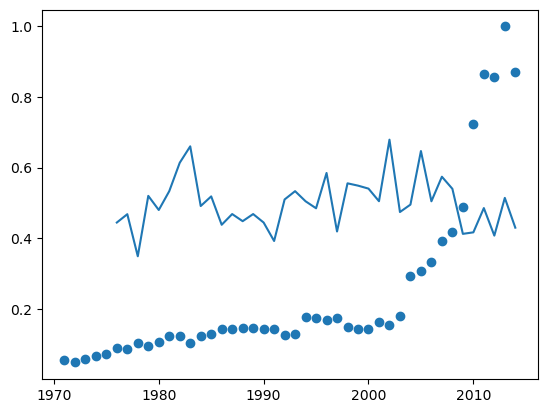

In [22]:
newbie_count = books_tt.groupby('release_year')['new_author'].sum()

years = newbie_count.index.values
values = newbie_count.values

plt.scatter(years, values/np.max(values))
plt.plot([year[0] for year in cv_result['val_year']], cv_result['f1_score'], label='f1 score')


### Updated features to include effects of new authors

In [25]:
books_tt_copy = books_tt.copy()

books_tt_copy['author_success_fraction'] = books_tt_copy['Total_Awards_Previously'] / books_tt_copy['author_num_books']

numerical_features = ["Author_Age_at_Publication", 'author_success_fraction', 'publisher_historical_nominations']
categorical_features = ["first_publisher", "month_of_publication"]
mlb_features = ["tags"]
bool_features = ["new_author"]

features = numerical_features + categorical_features + list(tag_dataframe.columns) + ['release_year'] + bool_features

# for each categorical feature, create one-hot encoding
categorical_pipeline = Pipeline(
    steps=[
        ('solve_nans', SimpleImputer(fill_value='Unknown', strategy='constant')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ] 
)

# numerical features: z-score normalization with the rest of the year.
# turn bool features to int
# calculate similarities
feature_preprocessing = ColumnTransformer(
    transformers=[
        ('numerical_scaling', YearByYearStandardScaler(year_column='release_year', scale_columns=numerical_features), numerical_features + ['release_year']),
        ('bool_to_int', FunctionTransformer(lambda x: x.astype(int), feature_names_out='one-to-one'), bool_features),
        ('onehot', categorical_pipeline, categorical_features),
    ('tag_similarity', YearlyGenreTagScaler(tag_columns=list(tag_dataframe.columns), year_column='release_year'), list(tag_dataframe.columns) + ['release_year']) ,
    ('nominee_similarity', YearlyPastNomineeSimilarityScaler(tag_columns=list(tag_dataframe.columns), year_column='release_year'), list(tag_dataframe.columns) + ['release_year'])    ],
)

In [27]:
model_lgb = Pipeline(steps=[
    ('preprocess', feature_preprocessing),
    ('lgb_rank', lgb.LGBMRanker(
        objective="lambdarank",
        n_estimators=300,
        label_gain=[0, 1],
        random_state=42,
        verbose=-1
    ))
])

windows = walk_forward(books_tt_copy)

In [28]:

cv_data_lgb = []
for num, fold in enumerate(windows):
    book_train = fold[0]
    book_val = fold[1]
    book_train = book_train.copy()
    book_val = book_val.copy()
    year = book_val['release_year'].mode()

    # LightGBM needs data sorted by group, with contiguous group sizes
    book_train = book_train.sort_values('release_year')
    group_sizes = book_train.groupby('release_year', sort=True).size().to_numpy()

    model_lgb.fit(
        book_train[features],
        book_train['target'],
        lgb_rank__group=group_sizes,
    )

    ypred = model_lgb.predict(book_val[features])
    book_val['predicted_score'] = ypred
    book_val['rank_within_year'] = book_val.groupby('release_year')['predicted_score'].rank(
        method='first',
        ascending=False
    )

    book_val['predicted'] = (book_val['rank_within_year'] <= num_finalists).astype(int)
    f1score = f1_score(book_val['target'], book_val['predicted'].values)
    recall = recall_score(book_val['target'], book_val['predicted'].values)
    precision = average_precision_score(book_val['target'], book_val['predicted'].values)

    # Precision@6 and NDCG@6, computed per year then averaged over the fold
    prec_at_k_list = []
    ndcg_at_k_list = []
    for yr, grp in book_val.groupby('release_year'):
        y_true = grp['target'].values.astype(int)
        y_score = grp['predicted_score'].values
        if y_true.sum() == 0:
            continue  # no finalists this year, metrics undefined
        top_k = grp.nsmallest(K, 'rank_within_year')
        prec_at_k_list.append(top_k['target'].values.astype(int).sum() / K)
        ndcg_at_k_list.append(ndcg_score([y_true], [y_score], k=K))

    prec_at_6 = np.mean(prec_at_k_list)
    ndcg_at_6 = np.mean(ndcg_at_k_list)

    cv_data_lgb.append({
        'fold': num,
        'val_year': year.values,
        'f1_score': f1score,
        'recall': recall,
        'precision': precision,
        'precision_at_6': prec_at_6,
        'ndcg_at_6': ndcg_at_6,
    })
    print(num)

/home/rudolph/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(


0


/home/rudolph/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(


1


/home/rudolph/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(


...

36


/home/rudolph/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(


37


/home/rudolph/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(


38


In [29]:
cv_result = pd.DataFrame(cv_data_lgb)
print("Mean f1 score across folds: ", cv_result['f1_score'].mean())
print("STD of f1 score across folds: ", cv_result['f1_score'].std())

Mean f1 score across folds:  0.5048765113121284
STD of f1 score across folds:  0.07151170075272607


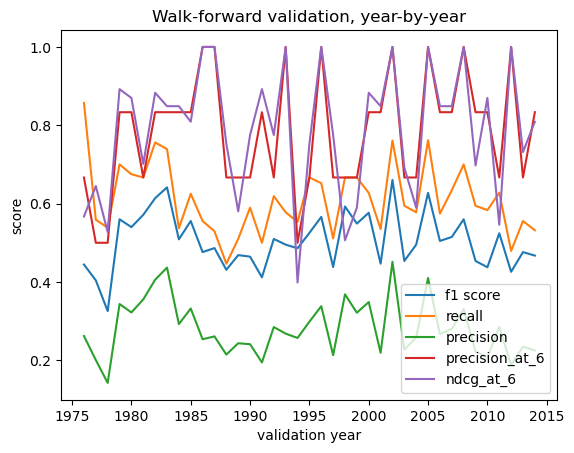

In [30]:
plt.plot([year[0] for year in cv_result['val_year']], cv_result['f1_score'], label='f1 score')
plt.plot([year[0] for year in cv_result['val_year']], cv_result['recall'], label='recall')
plt.plot([year[0] for year in cv_result['val_year']], cv_result['precision'], label='precision')
plt.plot([year[0] for year in cv_result['val_year']], cv_result['precision_at_6'], label='precision_at_6')
plt.plot([year[0] for year in cv_result['val_year']], cv_result['ndcg_at_6'], label='ndcg_at_6')
plt.xlabel("validation year")
plt.ylabel("score")
plt.title('Walk-forward validation, year-by-year')
plt.legend()

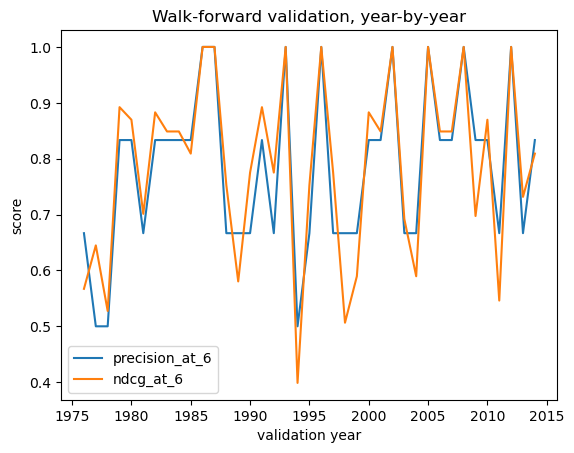

In [31]:
plt.plot([year[0] for year in cv_result['val_year']], cv_result['precision_at_6'], label='precision_at_6')
plt.plot([year[0] for year in cv_result['val_year']], cv_result['ndcg_at_6'], label='ndcg_at_6')
plt.xlabel("validation year")
plt.ylabel("score")
plt.title('Walk-forward validation, year-by-year')
plt.legend()

/home/rudolph/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 5.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<Axes: >

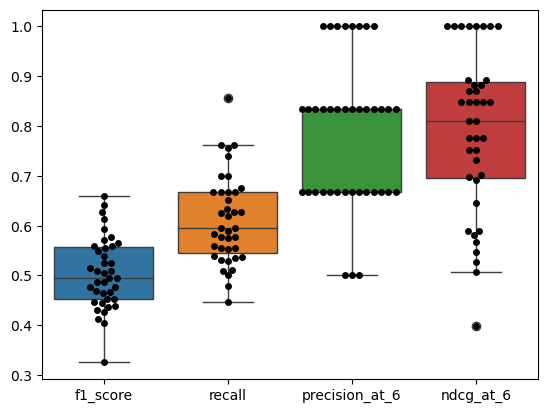

In [32]:
import seaborn as sns


ax = sns.boxplot(data=cv_result[['f1_score', 'recall', 'precision_at_6', 'ndcg_at_6']])

sns.swarmplot(data=cv_result[['f1_score', 'recall', 'precision_at_6', 'ndcg_at_6']], ax=ax, color='black')

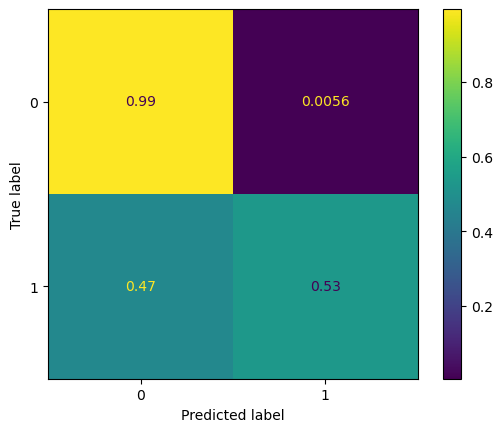

In [33]:
conf = confusion_matrix(book_val['target'], book_val['predicted'], normalize='true')#.ravel().tolist()

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(confusion_matrix=conf).plot()


In [34]:
print("names:", len(feature_names))
print("importances:", len(importances))

names: 82
importances: 82


In [35]:
feature_names = model_lgb.named_steps['preprocess'].get_feature_names_out()

importances = model_lgb.named_steps['lgb_rank'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(20))

                                              Feature  Importance
0        numerical_scaling__Author_Age_at_Publication        1633
1          numerical_scaling__author_success_fraction        1544
78         nominee_similarity__past_winner_similarity        1335
77                 tag_similarity__cohort_similiarity        1305
2   numerical_scaling__publisher_historical_nomina...        1242
73                    onehot__month_of_publication_10         110
29                   onehot__first_publisher_gollancz          94
76               onehot__month_of_publication_Unknown          92
3                             bool_to_int__new_author          91
65                    onehot__month_of_publication_02          79
5                       onehot__first_publisher_Other          79
42                      onehot__first_publisher_orbit          78
60                        onehot__first_publisher_tor          72
72                    onehot__month_of_publication_09          70
74        